# Sales data analysis 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#read ecomerce sales datasets excel file 
data = pd.read_excel(r"/Users/sanjaymagar/Desktop/Ecommerce Sales Analysis.xlsx")

In [3]:
df = data.copy()
data.head(2)

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [4]:
df.head(2)

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [5]:
df.Year.unique() #years

array([2013, 2012, 2011, 2014])

In [67]:
df.isna().sum()

Row ID             0
Order ID           0
Year               0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
Delivery Days      0
Profit Margin %    0
dtype: int64

In [7]:
df.size

219868

In [8]:
df.shape

(9994, 22)

In [9]:
#convert the date columns
# Converts date columns into proper datetime format.
# Why Important?
# Needed for:
# Year extraction
# Delivery time calculation
# Time-series analysis

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [10]:
#create delivery time column
# Calculates delivery duration.
# Business Insight
# Helps analyze:
# Shipping efficiency
# Fast vs slow delivery
# Shipping profitability

df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [11]:
# Profit Margin %
# Calculates percentage profit earned from sales.
# Business Insight
# Higher margin means better profitability.
df['Profit Margin %'] = (df['Profit']/ df['Sales']) * 100

# Sales and profiit Performace analysis

# KPI(Key Performance Indicator) analysis 

In [12]:
df.head(2)

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Delivery Days,Profit Margin %
0,1,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,3,16.0
1,2,CA-2013-152156,2013,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,3,30.0


In [13]:
#total Profit
total_profit = df['Profit'].sum()
print(f'Total Profit is = {total_profit}')

Total Profit is = 286397.0216999999


In [56]:
#total profit margin 
total_p_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100
total_p_margin

np.float64(12.4672172403156)

In [52]:
#total sales 
total_sales = df['Sales'].sum()
print(f'Total Profit is = {total_sales}')

Total Profit is = 2297200.8603000003


In [14]:
#Average Discount 
# Finds average discount given to customers.
# Business Meaning
# Higher discounts may reduce profits.
avg_discount = df['Discount'].mean()
print(f'Average Discount is = {avg_discount*100}')

Average Discount is = 15.620272163297976


In [15]:
#Total sold Quantity
# df.columns
sold_quantity = df['Quantity'].sum()
print(f'Total sold Quantity is ={sold_quantity}')

Total sold Quantity is =37873


In [65]:
#loss making Order
# counts orders where profit is negative.
# Business Meaning
# Helps identify:
# Loss-generating products
# Discount problems
# Operational inefficiencies

loss_order = df[df['Profit'] < 0]
print(f"the loss making order is = {loss_order.shape[0]}")
total_order = df.shape[0]


the loss making order is = 1871


In [66]:
# Loss order rate
loss_order_rate = (loss_order.shape[0] / total_order) * 100

print(f"Loss Making Order Rate = {loss_order_rate:}%")

Loss Making Order Rate = 18.721232739643785%


In [17]:
#Sales & Profit Performance 
#Create Year column
df['Year'] = df['Order Date'].dt.year

In [18]:
#sales by year 
profit_sale_year = df.groupby('Year')[['Sales','Profit']].sum().reset_index()
profit_sale_year

,Year,Sales,Profit
0,2011,484247.4981,49543.9741
1,2012,470532.5090,61618.6037
2,2013,608473.8300,81726.9308
3,2014,733947.0232,93507.5131


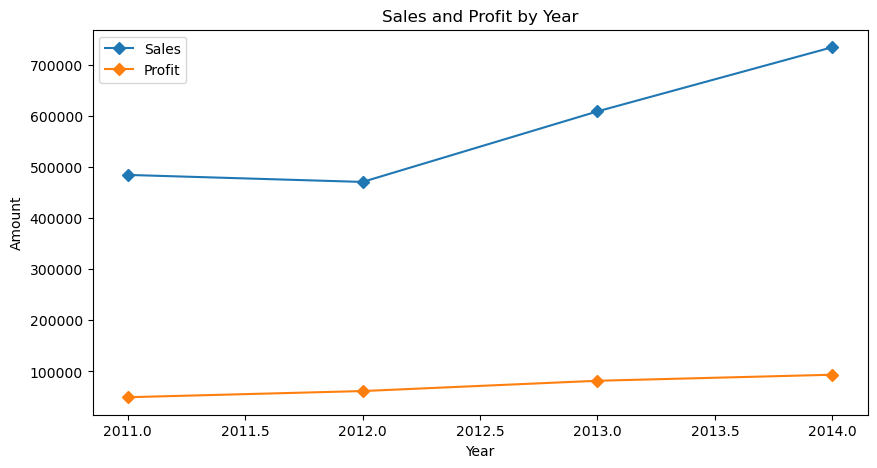

In [19]:
#visualization 
plt.figure(figsize=(10,5))
#plot sales line 
plt.plot(profit_sale_year['Year'],
         profit_sale_year['Sales'],
         marker='D',
         label='Sales')
#plot profit line 
plt.plot(profit_sale_year['Year'],
         profit_sale_year['Profit'],
         marker='D',
         label='Profit')

plt.title('Sales and Profit by Year')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()

plt.savefig('sales and profit by year.png')
plt.show()

In [20]:
# Sales and profit by Region 
#sales by Region 
sales_region = df.groupby('Region')['Sales'].sum().sort_values(ascending = False)
sales_region 

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [21]:
#profit by region
profit_region = df.groupby('Region')['Profit'].sum().sort_values(ascending = False)
profit_region 

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

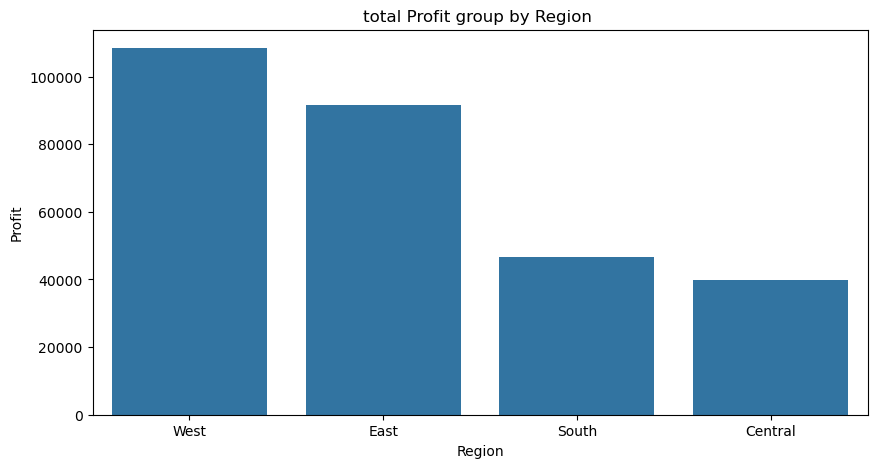

In [22]:
#visualization 
plt.figure(figsize = (10,5))
sns.barplot(x = profit_region.index,y = profit_region.values)
plt.xlabel('Region')
plt.ylabel('Profit')
plt.title('total Profit group by Region ')
plt.savefig('Total profit by region.png')
plt.show()

# BY  category and subcategory 

In [23]:

# data_cat = df.groupby('Category')['Profit'].sum().reset_index()
# data_cat
#OR Are same for visualization respectively
data_cat = df.groupby('Category')['Profit'].sum()
data_cat


Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

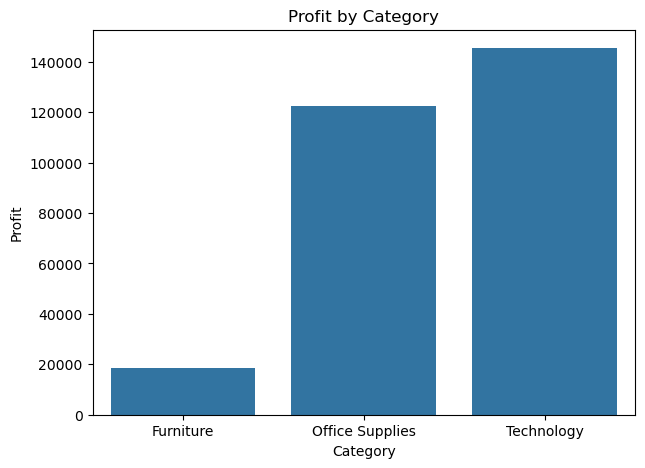

In [24]:
# #visualization by category 
# plt.figure(figsize=(7,5))
# sns.barplot(x='Category', y='Profit',data = data_cat)
# plt.title('Profit by Category')
# plt.xlabel('Category')
# plt.ylabel('Profit')
# plt.savefig('visualization of profit by category.png')
# plt.show()
#OR same for
plt.figure(figsize=(7,5))
sns.barplot(x=data_cat.index, y=data_cat.values)
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.savefig('visualization of profit by category.png')
plt.show()

In [25]:
#By subcategory 
df.columns
data_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()
data_subcat

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

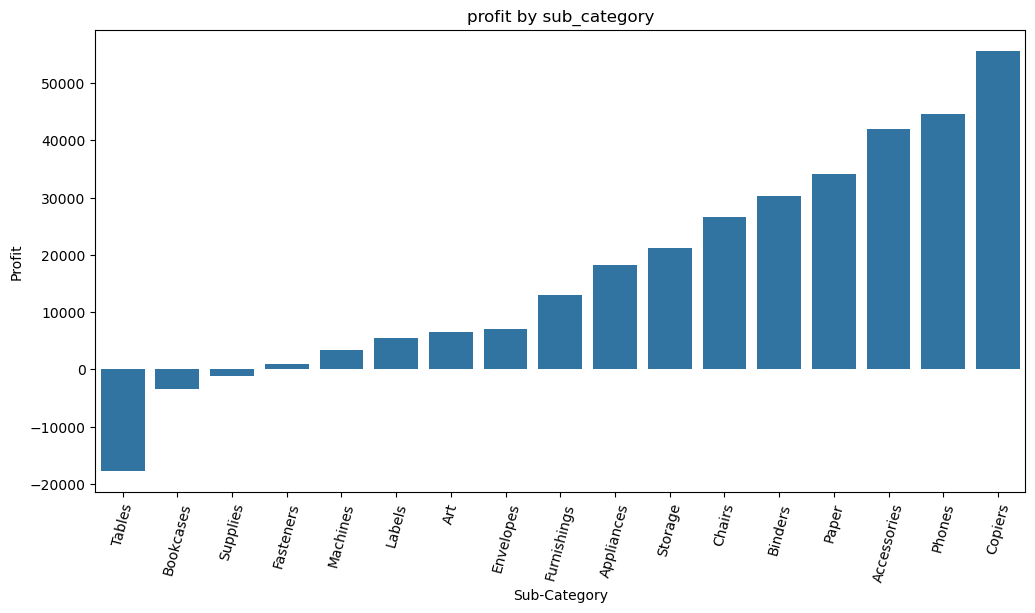

In [26]:
#visualization of total profit by  subcategory 
plt.figure(figsize=(12,6))
sns.barplot(x = data_subcat.index,y = data_subcat.values)
plt.xticks(rotation = 75)
plt.xlabel('Sub-Category')
plt.title('profit by sub_category')
plt.ylabel('Profit')
plt.savefig('visualization of total profit by  subcategory.png')
plt.show()

# Identify high-revenue but low-profit products.

In [27]:

data_pname = df.groupby('Product Name')[['Sales','Profit']].sum().reset_index()
data_pname

,Product Name,Sales,Profit
0,"""While you Were Out"" Message Book, One Form pe...",25.228,10.3880
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,16.7678
2,#10 Self-Seal White Envelopes,108.682,52.1230
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",488.904,223.1408
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,115.2806
...,...,...,...
1836,iKross Bluetooth Portable Keyboard + Cell Phon...,477.660,115.6440
1837,iOttie HLCRIO102 Car Mount,215.892,-11.9940
1838,iOttie XL Car Mount,223.888,-50.3748
1839,invisibleSHIELD by ZAGG Smudge-Free Screen Pro...,442.554,171.2648


In [28]:

high_sales_low_profit = data_pname[(data_pname['Sales']>data_pname['Sales'].mean())&(data_pname['Profit']<data_pname['Profit'].mean())]

high_sales_low_profit.sort_values(by='Sales',ascending = False).head(10)

,Product Name,Sales,Profit
443,Cisco TelePresence System EX90 Videoconferenci...,22638.4800,-1.811078e+03
784,HON 5400 Series Task Chairs for Big and Tall,21870.5760,3.979039e-13
681,GBC DocuBind P400 Electric Binding System,17965.0680,-1.878166e+03
811,High Speed Automatic Electric Letter Opener,17030.3120,-2.620048e+02
983,Lexmark MX611dhe Monochrome Laser Printer,16829.9010,-4.589973e+03
1041,Martin Yale Chadless Opener Electric Letter Op...,16656.2000,-1.299184e+03
1349,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.9656,-6.695448e+02
367,Bretford Rectangular Conference Table Tops,12995.2915,-3.272331e+02
474,Cubify CubeX 3D Printer Double Head Print,11099.9630,-8.879970e+03
497,DMI Eclipse Executive Suite Bookcases,11046.6090,9.017640e+01


# Discount Impact Analysis

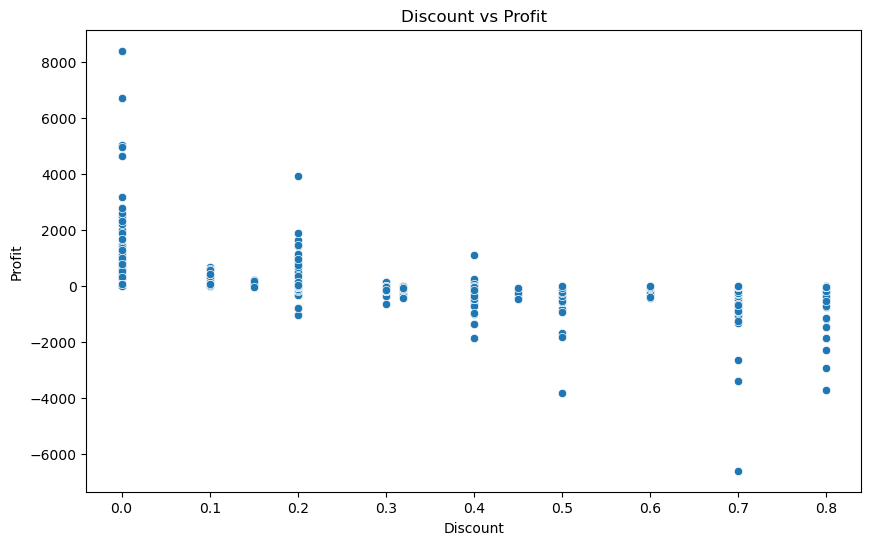

In [29]:
#discount vs profit 
#Shows relationship between discount and profit.
plt.figure(figsize=(10,6))
sns.scatterplot(x = 'Discount',y = 'Profit',data= df)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.savefig('Discount vs Profit.png')
plt.show()

In [30]:
#Average Profit by discount
discount_profit = df.groupby('Discount')['Profit'].mean().reset_index()
discount_profit

,Discount,Profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


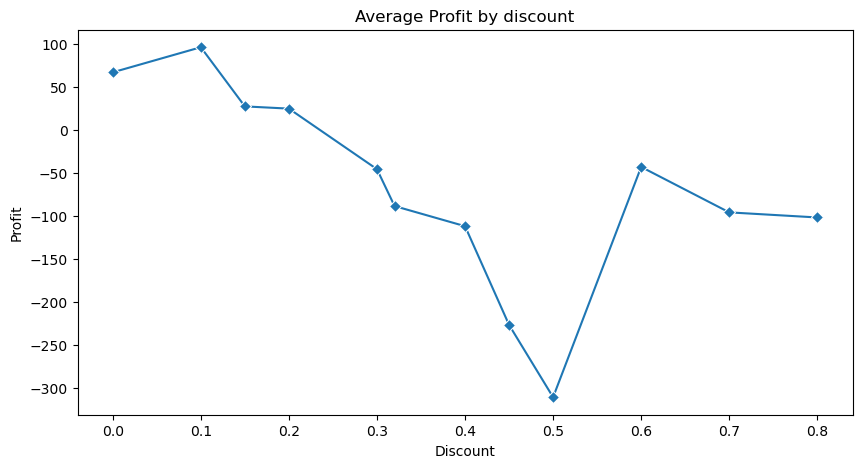

In [45]:
#visualization 
plt.figure(figsize=(10,5))
sns.lineplot(x = 'Discount', y = 'Profit',data = discount_profit,marker = 'D')
plt.title('Average Profit by discount')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.savefig('Average Profit by discount.png')
plt.show()

In [32]:
#Category Most Affected by Discounts
discount_cat = df.groupby('Category').agg({'Discount':'mean','Profit':'sum'})
discount_cat

,Discount,Profit
Category,,
Furniture,0.173923,18451.2728
Office Supplies,0.157285,122490.8008
Technology,0.132323,145454.9481


# Customer Segment Analysis

In [33]:
#Sales by segment 
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()
segment_sales

,Segment,Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


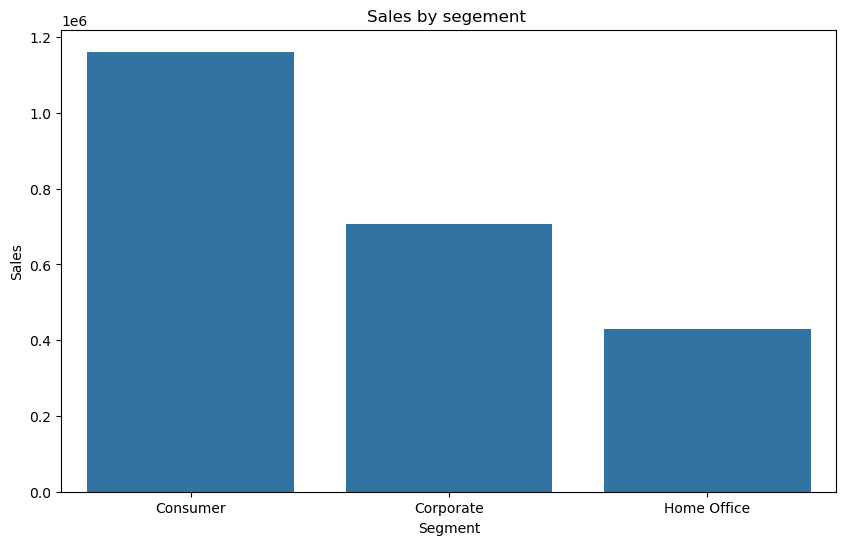

In [47]:
plt.figure(figsize=(10,6))
# sns.barplot(x = segment_sales.index,y = segment_sales.values)
sns.barplot(x = 'Segment',y = 'Sales',data = segment_sales)
plt.title('Sales by segement ')
plt.xlabel('Segment')
plt.ylabel('Sales')
plt.savefig('Sales by segement.png')
plt.show()

In [48]:
#Profit by segement 
segment_profit = df.groupby('Segment')['Profit'].sum().reset_index()
segment_profit

,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


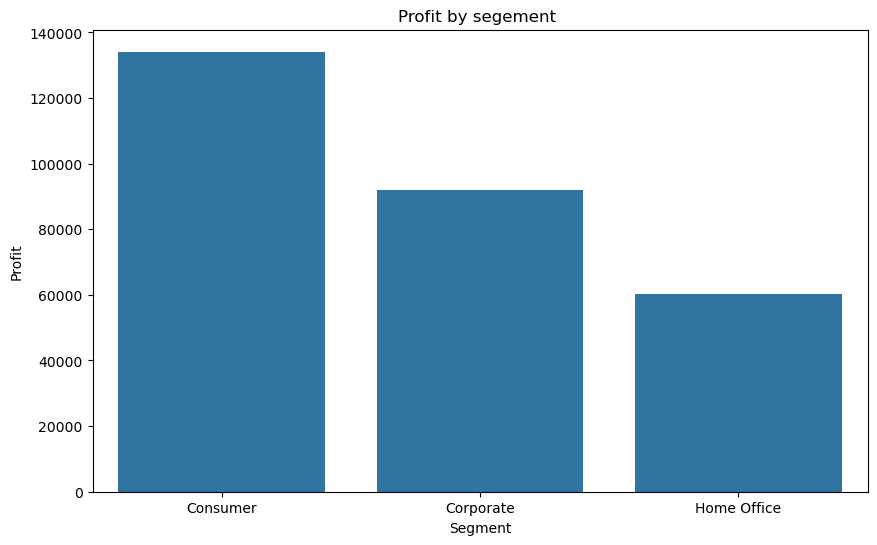

In [49]:
#Visualization
plt.figure(figsize=(10,6))
sns.barplot(x = 'Segment',y = 'Profit',data = segment_profit)
plt.title('Profit by segement ')
plt.xlabel('Segment')
plt.ylabel('Profit')
plt.savefig('Profit by segement.png')
plt.show()

# Top Customers

In [37]:
#Top Customers by Sales
data_top_coustumer_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).reset_index()
data_top_coustumer_sales.head(3)

,Customer Name,Sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339


# Customers Causing Loss

In [38]:
customer_loss = df.groupby('Customer Name')['Profit'].sum().sort_values().reset_index()
customer_loss

,Customer Name,Profit
0,Cindy Stewart,-6626.3895
1,Grant Thornton,-4108.6589
2,Luke Foster,-3583.9770
3,Sharelle Roach,-3333.9144
4,Henry Goldwyn,-2797.9635
...,...,...
788,Adrian Barton,5444.8055
789,Hunter Lopez,5622.4292
790,Sanjit Chand,5757.4119
791,Raymond Buch,6976.0959


# Shipping & Operational Efficiency

In [39]:
#Delivery Time by Ship Mode
ship_day = df.groupby('Ship Mode')['Delivery Days'].mean().reset_index()
ship_day
# df.columns

,Ship Mode,Delivery Days
0,First Class,2.182055
1,Same Day,0.044199
2,Second Class,3.240103
3,Standard Class,5.007205


In [40]:
#profit by ship mode
ship_profit = df.groupby('Ship Mode')['Profit'].sum().reset_index()
ship_profit

,Ship Mode,Profit
0,First Class,48969.8399
1,Same Day,15891.7589
2,Second Class,57446.6354
3,Standard Class,164088.7875


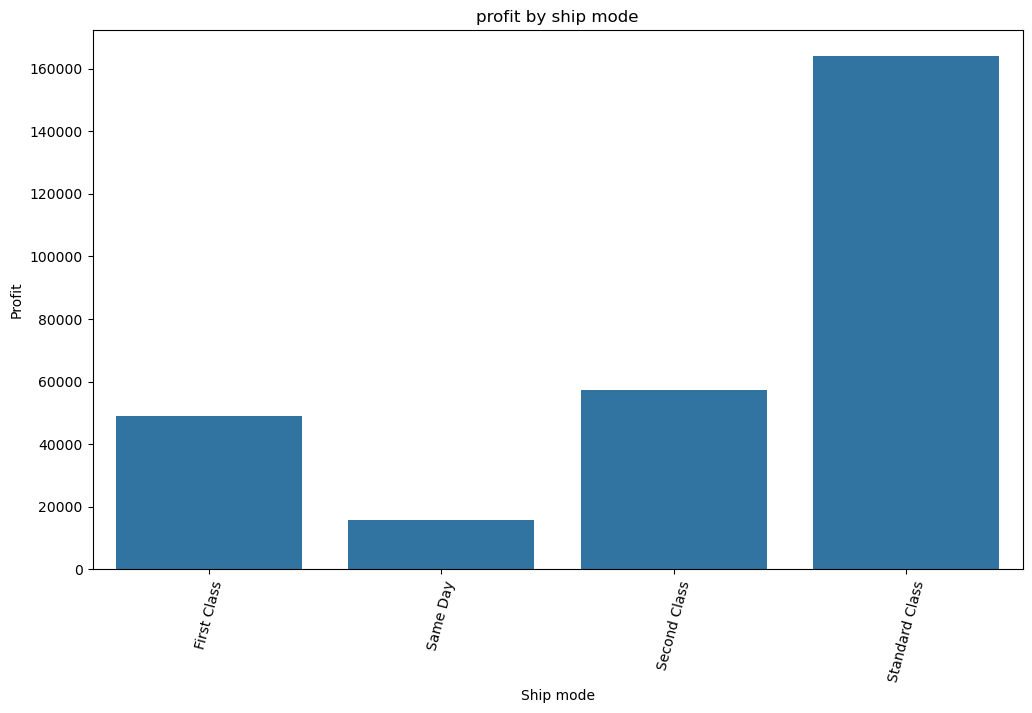

In [50]:
#visualization
plt.figure(figsize = (12,7))
sns.barplot(x = 'Ship Mode',y = 'Profit',data = ship_profit)
plt.title('profit by ship mode')
plt.xticks(rotation = 75)
plt.xlabel('Ship mode')
plt.ylabel('Profit')
plt.savefig('Profit by ship mode.png')
plt.show()

# Correlation Heatmap

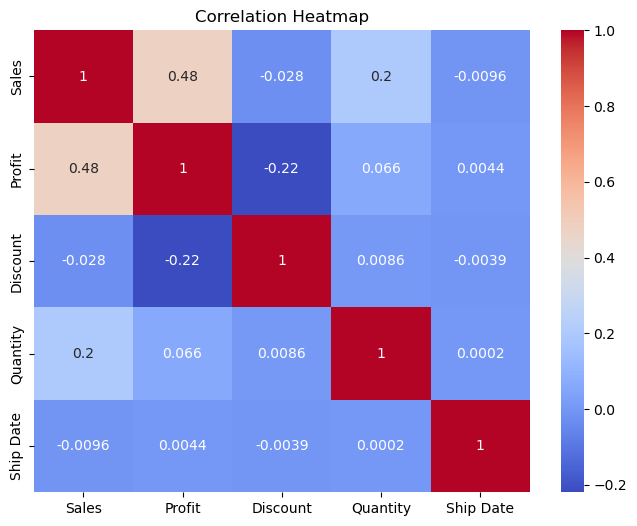

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Profit','Discount','Quantity','Ship Date']].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('Correlation Heatmap.png')
plt.show()

# Important Business Insights

In [43]:
print("1. Technology category usually generates highest profit.")
print("2. Furniture category often suffers losses due to heavy discounts.")
print("3. Discounts above 40% generally reduce profitability.")
print("4. Some products generate high sales but very low profit.")
print("5. Standard Class shipping is more cost-effective.")
print("6. Consumer segment usually contributes highest sales.")

1. Technology category usually generates highest profit.
2. Furniture category often suffers losses due to heavy discounts.
3. Discounts above 40% generally reduce profitability.
4. Some products generate high sales but very low profit.
5. Standard Class shipping is more cost-effective.
6. Consumer segment usually contributes highest sales.


# Final Recommendations

In [44]:
print("RECOMMENDATIONS")
print("---------------------------")
print("1. Reduce discounts above 40%.")
print("2. Focus marketing on Technology products.")
print("3. Re-price or discontinue loss-making products.")
print("4. Improve profitability in Furniture category.")
print("5. Promote Standard Class shipping.")
print("6. Target high-profit customers and segments.")

RECOMMENDATIONS
---------------------------
1. Reduce discounts above 40%.
2. Focus marketing on Technology products.
3. Re-price or discontinue loss-making products.
4. Improve profitability in Furniture category.
5. Promote Standard Class shipping.
6. Target high-profit customers and segments.
